# Assignment 5

In the previous exercises you have gotten detailed instructions about how to solve a predictive task step-by-step. In this week's exercise it will be the opposite: You are given full freedom to do as you choose, given that you are able to solve the task at hand relatively well, and reflect on your choices. The idea is that this should resemble what would happen in a real-life project, be it in research or in the industry: Then you will have few a priori answers to what preprocessing steps are necessary or what model is the best, but you will need to make choices, revise them as you go, and reflect upon the process afterwards.
The task is as follows:

# 1. Preprocess and check

Preprocess the dataset as you see fit.
- Fit non-linear models (GLM, GAM, RF, XGBoost) to predict Balance from the other variables in the dataset. You are not allowed to use the Income variable as a predictor, due to its high collinearity with Balance.
- Whether you fit one or more types of models is up to you, the same goes for the choice of hyperparameters and how you find them. However, you should aim for achieving good predictive performance, and being relatively certain the performance holds up in new data.
- In other words, using a train/validation/test-split or a (nested) cross-validation is probably a good idea. When you are satisfied, report model performance in a comprehensible manner.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from pygam import LinearGAM

In [16]:
# Load data
df = pd.read_csv("Credit.csv")

# Drop Income
df = df.drop("Income", axis=1)

# Convert Yes/No to 1/0
binary_cols = ["Own", "Student", "Married"]
for col in binary_cols:
    df[col] = (df[col] == "Yes").astype(int)

# One-hot encode Region
df = pd.get_dummies(df, columns=["Region"], drop_first=True)

# Separate features and target
X = df.drop("Balance", axis=1)
y = df["Balance"]

# Train/Val/Test split (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 240, Val: 80, Test: 80


In [17]:
print("Training set shape:", X_train.shape)
print("\nFirst few rows:")
print(X_train.head())

print("-" * 50)

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print("-" * 50)

# Check for outliers in numeric columns
print("\nNumeric features summary:")
print(X_train.describe())

Training set shape: (240, 10)

First few rows:
     Limit  Rating  Cards  Age  Education  Own  Student  Married  \
96    5382     367      1   59         17    0        1        0   
277   5000     353      2   50         12    0        0        1   
307   3874     298      3   41         14    1        0        1   
337    855     119      3   32         12    0        0        1   
248    905      93      1   38         16    0        1        1   

     Region_South  Region_West  
96          False         True  
277          True        False  
307         False         True  
337         False        False  
248          True        False  
--------------------------------------------------
Missing values:
Limit           0
Rating          0
Cards           0
Age             0
Education       0
Own             0
Student         0
Married         0
Balance         0
Region_South    0
Region_West     0
dtype: int64
--------------------------------------------------

Numeric features

## Check linear models for each feature

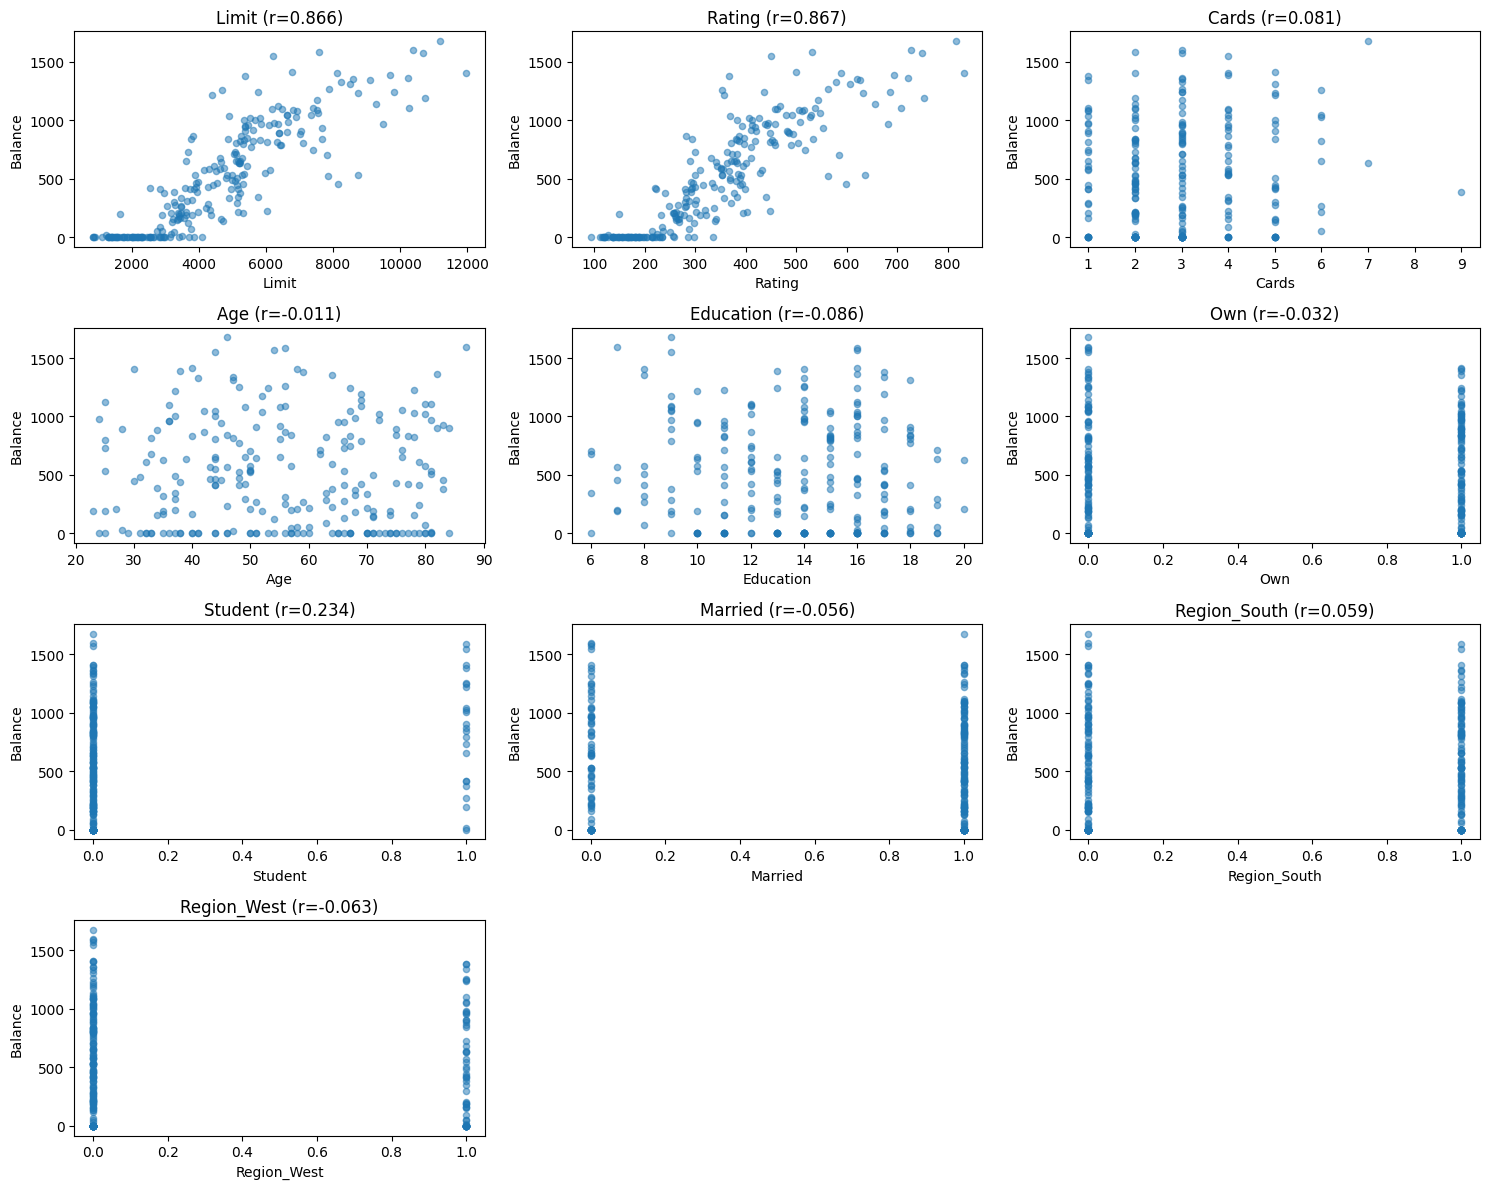

In [18]:
n_features = len(X_train.columns)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

correlations = X_train.corrwith(y_train)

for idx, feature in enumerate(X_train.columns):
    axes[idx].scatter(X_train[feature], y_train, alpha=0.5, s=20)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel("Balance")
    axes[idx].set_title(f"{feature} (r={correlations[feature]:.3f})")

for idx in range(n_features, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

## Feature correlations to target and other features

Correlations with balance
Rating         :  0.867
Limit          :  0.866
Student        :  0.234
Education      : -0.086
Cards          :  0.081
Region_West    : -0.063
Region_South   :  0.059
Married        : -0.056
Own            : -0.032
Age            : -0.011


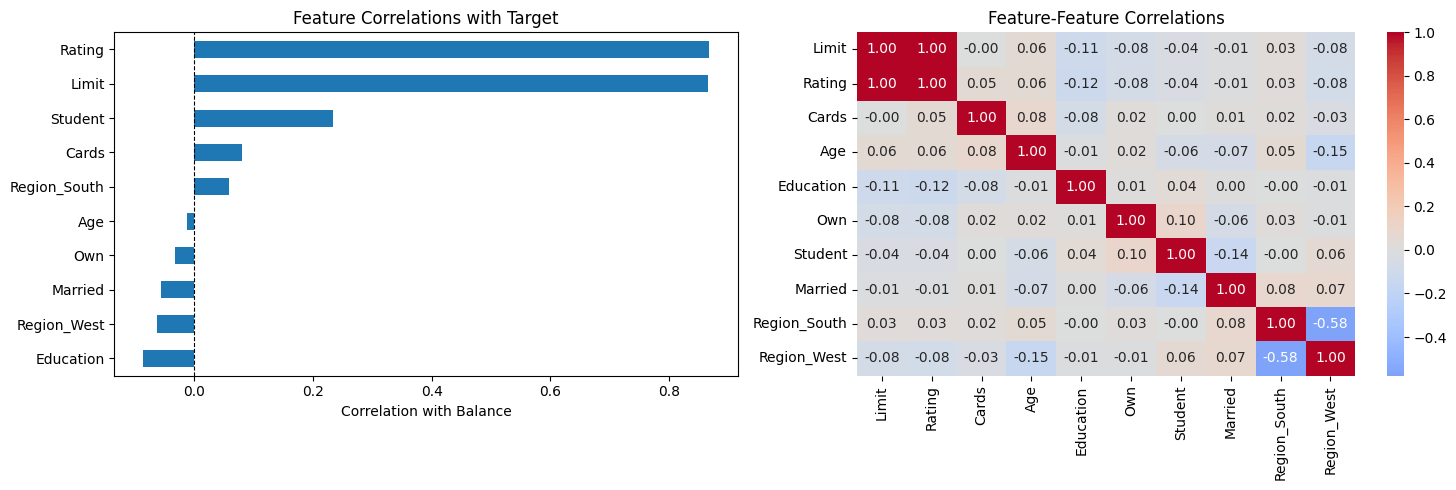

In [19]:
# Correlation with target
print("Correlations with balance")
correlations = X_train.corrwith(y_train).sort_values(key=abs, ascending=False)
for feature, corr in correlations.items():
    print(f"{feature:15s}: {corr:6.3f}")

# Visualize correlations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
correlations.sort_values().plot(kind="barh", ax=ax1)
ax1.set_xlabel("Correlation with Balance")
ax1.set_title("Feature Correlations with Target")
ax1.axvline(x=0, color="black", linestyle="--", linewidth=0.8)

# Feature-feature correlation heatmap (to check multicollinearity)
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax2)
ax2.set_title("Feature-Feature Correlations")

plt.tight_layout()
plt.show()

## 2. Fit and tune models

In [20]:
# 1. GAM Hyperparameter Tuning
X_train_int = X_train.astype(int).values  # Convert to numpy
X_val_int = X_val.astype(int).values

# Use pygam's built-in gridsearch
best_gam = LinearGAM().gridsearch(
    X_train_int, y_train.values, lam=np.logspace(-2, 3, 10), n_splines=[10, 15, 20, 25]  # Convert to numpy
)

print(f"GAM - Best lam: {best_gam.lam}")

# 2. GLM with Pipeline
glm_pipe = Pipeline(
    [("scaler", StandardScaler()), ("poly", PolynomialFeatures(degree=2, include_bias=False)), ("ridge", Ridge())]
)
glm_params = {"ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000]}
glm_search = GridSearchCV(glm_pipe, glm_params, cv=5, scoring="neg_root_mean_squared_error")
glm_search.fit(X_train, y_train)

# 3. Random Forest
rf_params = {"n_estimators": [100, 200, 300], "max_depth": [10, 20, 30, None], "min_samples_split": [2, 5, 10]}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
)
rf_search.fit(X_train, y_train)

# 4. XGBoost
xgb_params = {"n_estimators": [50, 100, 200], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.05, 0.1]}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42), xgb_params, n_iter=20, cv=5, scoring="neg_root_mean_squared_error", random_state=42
)
xgb_search.fit(X_train, y_train)

  0% (0 of 40) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  2% (1 of 40) |                         | Elapsed Time: 0:00:00 ETA:   0:00:02
  7% (3 of 40) |#                        | Elapsed Time: 0:00:00 ETA:   0:00:01
 10% (4 of 40) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:01
 15% (6 of 40) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:01
 20% (8 of 40) |#####                    | Elapsed Time: 0:00:00 ETA:   0:00:01
 25% (10 of 40) |######                  | Elapsed Time: 0:00:00 ETA:   0:00:01
 30% (12 of 40) |#######                 | Elapsed Time: 0:00:00 ETA:   0:00:01
 37% (15 of 40) |#########               | Elapsed Time: 0:00:00 ETA:   0:00:00
 42% (17 of 40) |##########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 47% (19 of 40) |###########             | Elapsed Time: 0:00:00 ETA:   0:00:00
 50% (20 of 40) |############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 57% (23 of 40) |#############          

GAM - Best lam: [[np.float64(5.994842503189409)], [np.float64(5.994842503189409)], [np.float64(5.994842503189409)], [np.float64(5.994842503189409)], [np.float64(5.994842503189409)], [np.float64(5.994842503189409)], [np.float64(5.994842503189409)], [np.float64(5.994842503189409)], [np.float64(5.994842503189409)], [np.float64(5.994842503189409)]]


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=42, ...),
                   n_iter=20,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='neg_root_mean_squared_error')

## Model performance on validation set

In [21]:
# Compare on validation set
print(f"\nValidation Results:")
models_val = {
    "GAM": best_gam.predict(X_val_int),
    "GLM": glm_search.predict(X_val),
    "RF": rf_search.predict(X_val),
    "XGBoost": xgb_search.predict(X_val),
}

for name, pred in models_val.items():
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2 = r2_score(y_val, pred)
    print(f"{name} - RMSE: {rmse:.2f}, R²: {r2:.3f}")


Validation Results:
GAM - RMSE: 169.08, R²: 0.893
GLM - RMSE: 206.84, R²: 0.840
RF - RMSE: 194.43, R²: 0.858
XGBoost - RMSE: 196.00, R²: 0.856


## Model performance on test set

In [22]:
# Test set evaluation for all models
X_test_int = X_test.astype(int).values

results = {}
# GAM
test_pred = best_gam.predict(X_test_int)
results["GAM"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
    "MAE": mean_absolute_error(y_test, test_pred),
    "R²": r2_score(y_test, test_pred),
}

# Other models
for name, model in [
    ("GLM", glm_search.best_estimator_),
    ("RF", rf_search.best_estimator_),
    ("XGBoost", xgb_search.best_estimator_),
]:
    test_pred = model.predict(X_test)
    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "MAE": mean_absolute_error(y_test, test_pred),
        "R²": r2_score(y_test, test_pred),
    }

# Display results
for name, metrics in results.items():
    print(f"{name}:")
    print(f"  RMSE: {metrics['RMSE']:.2f}")
    print(f"  MAE: {metrics['MAE']:.2f}")
    print(f"  R²: {metrics['R²']:.3f}\n")

GAM:
  RMSE: 213.27
  MAE: 162.73
  R²: 0.728

GLM:
  RMSE: 234.46
  MAE: 174.33
  R²: 0.671

RF:
  RMSE: 220.13
  MAE: 157.73
  R²: 0.710

XGBoost:
  RMSE: 208.54
  MAE: 156.27
  R²: 0.740



## Plot models on test set

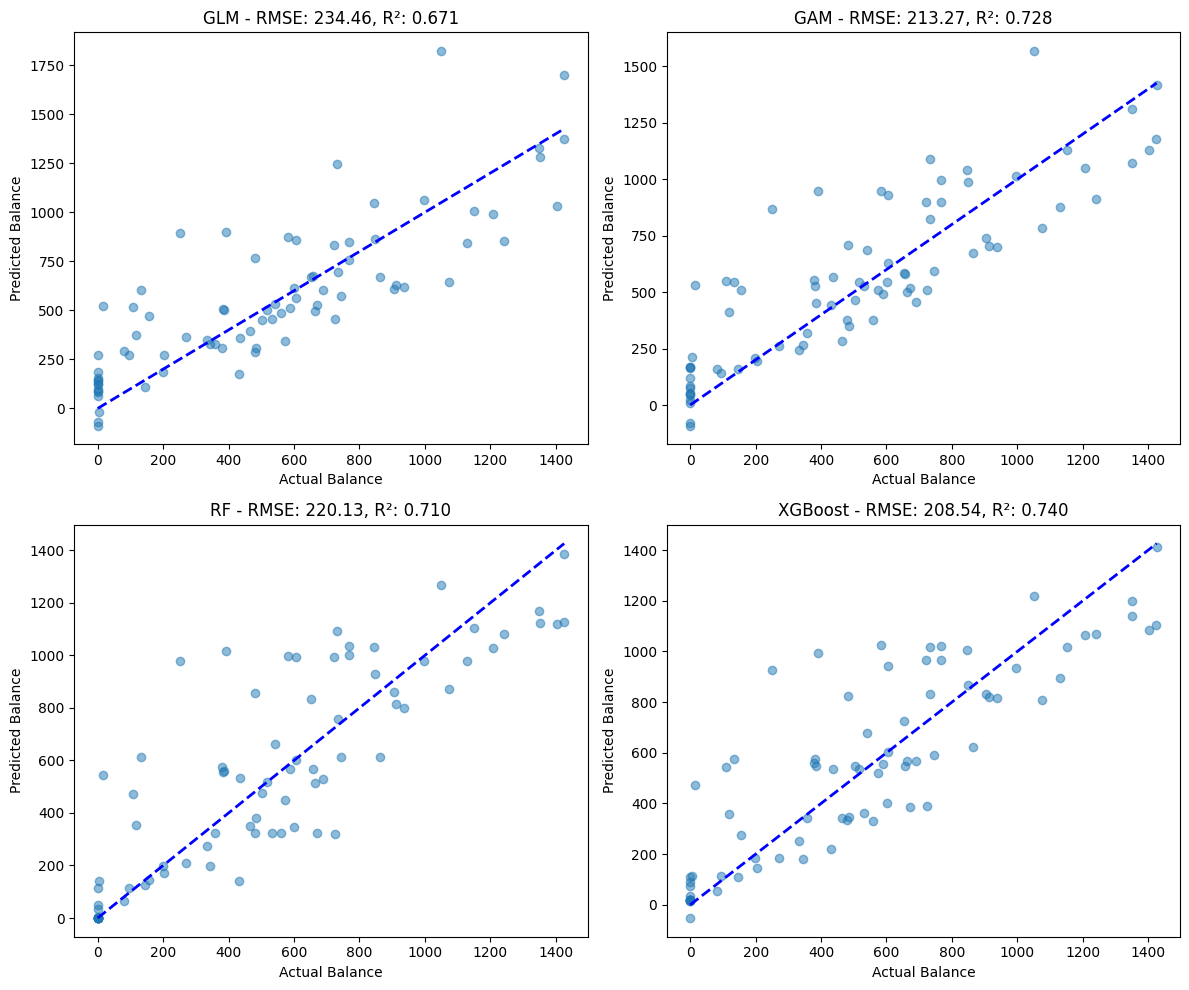

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

models_list = [
    ("GLM", glm_search.best_estimator_, X_test),
    ("GAM", best_gam, X_test_int),
    ("RF", rf_search.best_estimator_, X_test),
    ("XGBoost", xgb_search.best_estimator_, X_test),
]

for idx, (name, model, X_data) in enumerate(models_list):
    pred = model.predict(X_data)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    axes[idx].scatter(y_test, pred, alpha=0.5)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "b--", lw=2)
    axes[idx].set_xlabel("Actual Balance")
    axes[idx].set_ylabel("Predicted Balance")
    axes[idx].set_title(f"{name} - RMSE: {rmse:.2f}, R²: {r2:.3f}")

plt.tight_layout()
plt.show()

## 3. Reflections

## Reflect on the choices you made:
## Why did you choose the model(s) you did?

- I chose the four models that were mentioned as examples for the task: GLM, GAM, RF, XGBoost. I don't have much experience with GLM and GAM, so I thought they were extra interesting to work with. I have interpreted the model complexity as: GLM < GAM < RF < XGBoost, and model interpretability as GLM > GAM > RF > XGBoost, so I saw some value in including all four.

## What about the hyperparameters? How did you tune them?
- I used different techniques to tune the hyperparameters instead of adjusting them manually, e.g.: GridSearchCV for GLM, RandomizedSearchCV for RF and XGBoost, and pygam's built-in gridsearch for GAM. They were tuned on training data, before I compared the models on the validation set before the final test evaluation.

## Reflect upon the performance of the model(s):
## How well did it/they perform?
XGBoost performed best on the test set (RMSE: 208.54, R²: 0.740), followed by GAM (213.27, 0.728), RF (220.13, 0.710), and GLM (234.46, 0.671). All models explain around 67-74% of variance in Balance, which I believe is quite reasonable for our data. The complexity-interpretability trade-off is clear: XGBoost had the best performance but GAM offers better interpretability with quite similar results. Interestingly, GAM had the best validation performance (169.08 RMSE) but dropped on test data, while XGBoost showed the opposite pattern, indicating variablity between the splits.

## What would you expect the performance to be on new data? How can you argue this is the case? What other choices could have made you more or less certain about this?

I expect the model performance to be similar to or slightly worse than test performance (RMSE ~210, R²~0.70). The train/val/test split helps prevent overfitting to test data. However, three factors make me less certain:

- First, the test set only has 80 samples, so there's natural variance in the estimates. A different random split could give somewhat different numbers - the GAM's 44-point jump in RMSE from validation to test sets likely reflects this.
- Second, using a single train/val/test split is less robust than nested cross-validation. Nested CV would average performance across multiple splits, giving more stable estimates, though at higher computational cost.
- Third, our one-hot encoding drops one Region category (the reference level). If new data contained patterns specific to that dropped region, or encountered a completely new region like "North" that wasn't in training data, the model would struggle. This is a concern for deployment.

Despite these limitations, I believe some of the performance could partially hold up on similar data from the same distribution.